# Satellite Images of Water Bodies - U-Net Segmentation

A collection of water bodies images captured by the Sentinel-2 Satellite. Each image comes with a black and white mask where white represents water and black represents something else but water. The masks were generated by calculating the NWDI (Normalized Water Difference Index).

Dataset: https://www.kaggle.com/datasets/franciscoescobar/satellite-images-of-water-bodies

## Import Libraries

In [ ]:
!pip install opencv-python
!pip install tensorflow

In [ ]:
import kagglehub
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

## Import the Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("franciscoescobar/satellite-images-of-water-bodies")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'satellite-images-of-water-bodies' dataset.
Path to dataset files: /kaggle/input/satellite-images-of-water-bodies


In [ ]:
# Take a look at the first 5 images and masks
for root, dirs, files in os.walk(path):
    print(root)
    for name in files[:5]:
        print("   ", name)

/kaggle/input/satellite-images-of-water-bodies
/kaggle/input/satellite-images-of-water-bodies/Water Bodies Dataset
/kaggle/input/satellite-images-of-water-bodies/Water Bodies Dataset/Images
    water_body_1219.jpg
    water_body_1350.jpg
    water_body_6378.jpg
    water_body_1494.jpg
    water_body_907.jpg
/kaggle/input/satellite-images-of-water-bodies/Water Bodies Dataset/Masks
    water_body_1219.jpg
    water_body_1350.jpg
    water_body_6378.jpg
    water_body_1494.jpg
    water_body_907.jpg


In [ ]:
# Define masks and images path
dataset_path = os.path.join(path, "Water Bodies Dataset")
images_dir = os.path.join(dataset_path, "Images")
masks_dir  = os.path.join(dataset_path, "Masks")

print(len(os.listdir(images_dir)), "images")
print(len(os.listdir(masks_dir)), "masks")

2841 images
2841 masks


Image shape: (483, 461, 3), dtype: uint8
Mask shape: (483, 461), dtype: uint8
Mask unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  47 212 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245
 246 247 248 249 250 251 252 253 254 255]


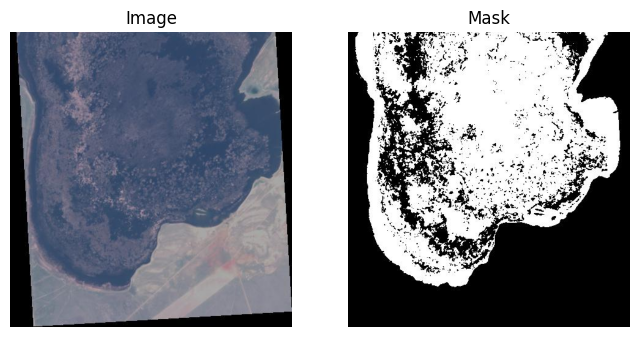

In [ ]:
# Sanity check to make sure the mask is black and white
img_name = os.listdir(images_dir)[0]

image = cv2.imread(os.path.join(images_dir, img_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(masks_dir, img_name), cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Mask shape: {mask.shape}, dtype: {mask.dtype}")
print(f"Mask unique values: {np.unique(mask)}")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

## Preprocessing con Generadores

En vez de cargar todas las imágenes en un array NumPy (lo que consumía toda la RAM), usamos un pipeline `tf.data` que lee las imágenes del disco bajo demanda, batch por batch. Así la RAM que se usa es proporcional al batch size, no al dataset completo.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 16

# Crear listas de paths (solo strings, no imágenes en memoria)
all_filenames = sorted(os.listdir(images_dir))

# Filtrar solo los que tienen máscara correspondiente
all_filenames = [f for f in all_filenames if os.path.exists(os.path.join(masks_dir, f))]

image_paths = [os.path.join(images_dir, f) for f in all_filenames]
mask_paths  = [os.path.join(masks_dir, f) for f in all_filenames]

print(f"Total de pares imagen-máscara: {len(image_paths)}")

Total de pares imagen-máscara: 2841


In [ ]:
# Train/Val split sobre los paths (no sobre las imágenes)
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

print(f"Train: {len(train_img_paths)} pares")
print(f"Val:   {len(val_img_paths)} pares")

Train: 2272 pares
Val:   569 pares


In [ ]:
# Función que lee y preprocesa UNA imagen desde disco
def load_and_preprocess(image_path, mask_path):
    """Lee imagen y máscara del disco, redimensiona y normaliza."""
    # Leer imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # Leer máscara
    msk = tf.io.read_file(mask_path)
    msk = tf.image.decode_jpeg(msk, channels=1)
    msk = tf.image.resize(msk, [IMG_SIZE, IMG_SIZE])
    msk = tf.cast(msk, tf.float32) / 255.0
    # Binarizar
    msk = tf.cast(msk > 0.5, tf.float32)

    return img, msk

In [ ]:
# Data augmentation (se aplica solo al set de entrenamiento)
def augment(image, mask):
    """Aplica augmentation consistente a imagen y máscara."""
    # Concatenar para aplicar las mismas transformaciones espaciales
    combined = tf.concat([image, mask], axis=-1)  # (H, W, 4)

    # Flips aleatorios
    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)

    # Separar de vuelta
    image = combined[..., :3]
    mask = combined[..., 3:]

    # Augmentation solo en la imagen (no en la máscara)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

In [ ]:
# Construir pipelines tf.data

# Train: lee del disco -> augmentation -> batch -> prefetch
train_ds = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
train_ds = train_ds.shuffle(len(train_img_paths))
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Val: lee del disco -> batch -> prefetch (SIN augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Verificar que funciona
for images, masks in train_ds.take(1):
    print(f"Batch de imágenes: {images.shape}, dtype: {images.dtype}")
    print(f"Batch de máscaras: {masks.shape}, dtype: {masks.dtype}")
    print(f"Rango imagen: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
    print(f"Valores únicos máscara: {np.unique(masks.numpy())}")

Batch de imágenes: (16, 128, 128, 3), dtype: <dtype: 'float32'>
Batch de máscaras: (16, 128, 128, 1), dtype: <dtype: 'float32'>
Rango imagen: [0.00, 0.84]
Valores únicos máscara: [0. 1.]


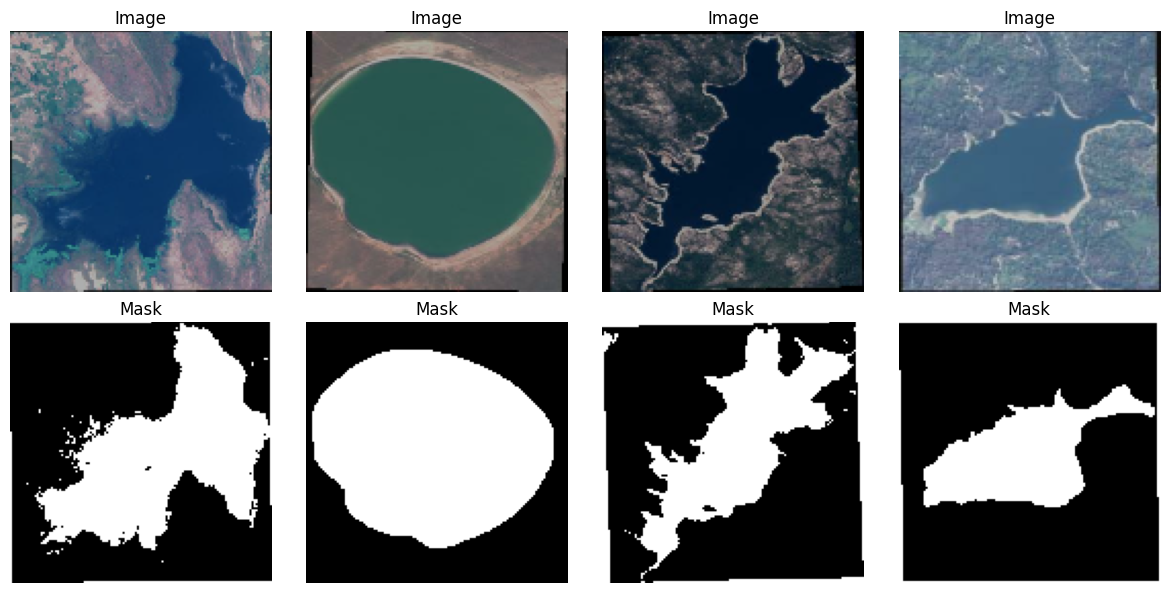

In [ ]:
# Visualizar un batch de ejemplo con augmentation
for images, masks in train_ds.take(1):
    plt.figure(figsize=(12, 6))
    for i in range(4):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2, 4, i + 5)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Mask")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Model Definition

Arquitectura U-Net estándar con:
- Encoder: 4 bloques de convolución + MaxPooling
- Bottleneck
- Decoder: 4 bloques de upsampling + skip connections
- Dropout en las capas profundas para regularización

In [ ]:
# Bloque de convolución
def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x

In [ ]:
# Construir U-Net
def build_unet(input_shape=(128, 128, 3)):

    inputs = layers.Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256, dropout_rate=0.2)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, 512, dropout_rate=0.2)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, 1024, dropout_rate=0.3)

    # Decoder
    u1 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(bn)
    u1 = layers.Concatenate()([u1, c4])
    c5 = conv_block(u1, 512, dropout_rate=0.2)

    u2 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = layers.Concatenate()([u2, c3])
    c6 = conv_block(u2, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = layers.Concatenate()([u3, c2])
    c7 = conv_block(u3, 128)

    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = layers.Concatenate()([u4, c1])
    c8 = conv_block(u4, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    model = Model(inputs, outputs)
    return model

In [ ]:
model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Loss Functions & Metrics

Se calcula el Dice loss por imagen individual y se promedia, en vez de aplanar todo el batch en un solo vector.

In [ ]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    # Aplanar por imagen: (batch, H*W*1)
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    dice = (2. * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(1.0 - dice)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)


def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    return tf.reduce_mean((2. * intersection + smooth) / (union + smooth))


def iou_metric(y_true, y_pred, smooth=1e-6):
    """Intersection over Union - métrica estándar para segmentación."""
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred_bin, [tf.shape(y_pred_bin)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1) - intersection

    return tf.reduce_mean((intersection + smooth) / (union + smooth))

## Training

In [ ]:
# Compilar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef, iou_metric]
)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_unet_model.keras',
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# Entrenar
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
113/142 ━━━━━━━━━━━━━━━━━━━━ 15:09 31s/step - accuracy: 0.7723 - dice_coef: 0.5117 - iou_metric: 0.4836 - loss: 0.9893

## Evaluation

In [ ]:
# Gráficas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].legend()
axes[0].set_xlabel('Epoch')

# Dice coefficient
axes[1].plot(history.history['dice_coef'], label='Train')
axes[1].plot(history.history['val_dice_coef'], label='Val')
axes[1].set_title('Dice Coefficient')
axes[1].legend()
axes[1].set_xlabel('Epoch')

# IoU
axes[2].plot(history.history['iou_metric'], label='Train')
axes[2].plot(history.history['val_iou_metric'], label='Val')
axes[2].set_title('IoU (Intersection over Union)')
axes[2].legend()
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluar en validación
results = model.evaluate(val_ds)
print(f"\nVal Loss: {results[0]:.4f}")
print(f"Val Accuracy: {results[1]:.4f}")
print(f"Val Dice Coefficient: {results[2]:.4f}")
print(f"Val IoU: {results[3]:.4f}")

In [ ]:
# Cargar solo unas pocas imágenes de validación para visualizar
sample_images = []
sample_masks = []

for img_path, msk_path in zip(val_img_paths[:10], val_mask_paths[:10]):
    img, msk = load_and_preprocess(img_path, msk_path)
    sample_images.append(img)
    sample_masks.append(msk)

sample_images = tf.stack(sample_images)
sample_masks = tf.stack(sample_masks)

# Predecir
pred = model.predict(sample_images)

In [ ]:
# Visualización de resultados
n_examples = 5

plt.figure(figsize=(16, 3.5 * n_examples))

for i in range(n_examples):
    # Imagen original
    plt.subplot(n_examples, 4, i * 4 + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title("Image")
    plt.axis("off")

    # Máscara real
    plt.subplot(n_examples, 4, i * 4 + 2)
    plt.imshow(sample_masks[i].numpy().squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    # Predicción (probabilidades)
    plt.subplot(n_examples, 4, i * 4 + 3)
    plt.imshow(pred[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title("Pred (Probability)")
    plt.axis("off")

    # Predicción binarizada
    plt.subplot(n_examples, 4, i * 4 + 4)
    plt.imshow(pred[i].squeeze() > 0.5, cmap="gray")
    plt.title("Pred Mask (>0.5)")
    plt.axis("off")

plt.tight_layout()
plt.show()